# Model Training

## Objective

The primary goal of this phase is to evaluate the efficacy of two distinct architectural approaches for Identity Recognition using ECG morphology. We aim to determine which paradigm best captures the unique "cardiac signature" of some part of individual patients within the PTB-XL dataset.

We are benchmarking a traditional Gradient Boosting approach against a modern Deep Learning architecture to solve the high-cardinality classification challenge (n_classes = 10,472).

### Approach A: CatBoost (GBDT)

Decision Tree Ensembles. Uses symmetric trees to find voltage-split thresholds.
Computationally heavy for 10k+ classes due to probability matrix overhead.

### Approach B: 1D-CNN (PyTorch)

Feature Learning. Uses convolutional kernels to "see" morphological textures.
Highly efficient for 10k+ classes via GPU-accelerated Softmax.

## Data Loading

Before beginning the training process, we need to load the required data from two files:
- The biometric data file containing ECG measurements
- The encoder file that maps patient identities to numerical representations

In [2]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import pickle

def load_biometric_data(
    file_path: Path = Path('../data/biometric_data.npz'),
    encoder_path: Path = Path('../data/patient_encoder.pkl')
) -> tuple[np.ndarray, np.ndarray, object]:
    """
    Load biometric data and patient encoder from specified file paths.
    
    Args:
        file_path (Path): Path to the compressed numpy array containing features and labels
        encoder_path (Path): Path to the pickled encoder object
        
    Returns:
        tuple: A tuple containing (features, encoded_labels, encoder)
        
    Raises:
        FileNotFoundError: If either the biometric data file or encoder file is not found
    """
    # Check if biometric data file exists
    if not file_path.exists():
        raise FileNotFoundError(f"Biometric data file not found at: {file_path}")
    
    # Check if encoder file exists
    if not encoder_path.exists():
        raise FileNotFoundError(f"Patient encoder file not found at: {encoder_path}")
    
    # Load the compressed numpy array data
    data = np.load(file_path)
    
    # Extract features (X) and encoded labels (Y)
    X = data['x']
    Y_encoded = data['y']
    
    # Load the encoder using pickle
    with open(encoder_path, 'rb') as f:
        encoder = pickle.load(f)
    
    return X, Y_encoded, encoder

try:
    X, Y_encoded, encoder = load_biometric_data()
except FileNotFoundError as e:
    print(f"Error: {e}")
    sys.exit(1)

## Dimensional Validation

This step performs critical validation checks to ensure our ECG data is properly structured before proceeding with model training or analysis.

### Data Structure Requirements

| Dimension | Expected Value | Purpose |
|-----------|---------------|---------|
| **Patients** | Variable | Confirms all filtered records were successfully processed |
| **Beats** | 10 | Validates that our QRS detection algorithm captured exactly 10 heartbeats per patient |
| **Leads** | 2 | Ensures both Lead I and Lead II are present for the 2-channel input required by our model |
| **Samples** | 200 | Verifies consistent time-series windowing across all beats |

> **Note:** Proper dimensional validation prevents downstream errors that could be difficult to diagnose during model training or evaluation phases.

In [3]:
if len(X) > 0:
    # Check the shape of the NumPy array
    # If successful, this should be (NumPatients, 10, 2, 200)
    print(f"Shape of X array: {X.shape}")
    print(f"Shape of Y array: {Y_encoded.shape}")
    
    # Check unique identities (classes), this should be 10472
    num_unique_patients = len(np.unique(Y_encoded))
    print(f"Number of unique patient identities: {num_unique_patients}")
    
    # Inspect a single sample for internal verification
    # X[0] is the first patient, X[0][0] is their first beat
    print(f"Shape of one patient's data: {X[0].shape}")
    print(f"Shape of a single beat: {X[0][0].shape}")
else:
    print("CRITICAL: X contains no data. Check your file paths or peak detection logic.")
    sys.exit(1)

Shape of X array: (10472, 10, 2, 200)
Shape of Y array: (10472,)
Number of unique patient identities: 10472
Shape of one patient's data: (10, 2, 200)
Shape of a single beat: (2, 200)


## Biometric Dataset Splitting Strategies

### Closed-Set Identification (Our Approach)

The model asks: "Which of these 10,742 known patients is this?" (N-class classification).

This means all 10,000 users in the Test set must also exist in the Train set. The model is learning to pick 1 out of 10,000 known people.

To do Closed-Set correctly you need multiple recordings for each of the 10,000 users.
Train: User A (Recording from January)
Test: User A (Recording from February)

But we have ONE recording per user that has been chopped into 10 pieces, meaning that we will measure how well the model identifies the user during that specific session.

### Open-Set Verification (Avoided Approach)

The model asks: "Is this heartbeat from Patient X, or is it an Unknown Intruder?" (Similarity detection).

Why it was avoided for CatBoost and CNN:

- **The "Softmax" Limitation**. Standard CNNs and CatBoost models use a Softmax output layer that is forced to distribute probabilities so they sum to 1.0. If an "Unknown" person provides an ECG, the model is forced to pick the "closest" match from your 10,742 patients, even if the match is poor. For Open-Set, you would need a "Reject" threshold or a different loss function (like Triplet Loss).

- **Complexity of "Negative" Sampling**. To train an Open-Set model, you need a way to teach the model what a "Non-Patient" looks like. Adding an "Unknown" category or training a Siamese Network (common for Open-Set) would double or triple the training time because you have to compare pairs of heartbeats rather than just classifying single ones. With 10,742 patients, your model is already struggling with memory and processing time.

- **Data Volume per Identity**. Since we have 10 heartbeats per patient, we have enough to "identify" them in a closed group, but we may not have enough variety to create a robust "Universal Background Model" that can reliably reject strangers without high False Rejection Rates (FRR).

# Gradient Boosting on Decision Trees (GBDT)

CatBoost is an advanced GBDT framework that excels in signal-based tasks like ECG classification. Unlike Random Forests which build independent trees, CatBoost constructs trees sequentially, with each new tree specifically targeting errors made by previous ones.

## Data Preparation for CatBoost Classification

### Challenge: High-Cardinality Multi-class Problems

When dealing with high-cardinality classification (such as identifying 10,472 unique patients from heartbeats), tree-based models face a significant computational bottleneck:

- For each boosting iteration, **CatBoost** must calculate gradients for all 10,472 potential patients per heartbeat
- This creates massive memory requirements and slow training times

### Solution: Class Count Reduction

**Strategy:** Begin by classifying only 50-500 patients instead of all 10,472.

**Benefits:**
- Reduces the N×K gradient matrix by approximately 99%
- Dramatically improves training speed from hours to seconds
- Allows for rapid model prototyping and iteration

This approach enables efficient model development before scaling to the full dataset.

In [6]:
from sklearn.model_selection import train_test_split

# Define a smaller subset of data to work with for faster model development
num_patients = 300  # Start small to unstick the model
X_subset = X[:num_patients]  # Take only the first 300 patients from the dataset
Y_subset = Y_encoded[:num_patients]  # Take corresponding labels

# Reshape the 4D data into 2D format required by most ML algorithms
# Original shape: (patients, 10 beats per patient, 2 channels, 200 time points)
# New shape: (patients*beats, channels*time points)
X_flat_subset = X_subset.reshape(-1, 2 * 200).astype('float32')  # Convert to float32 for memory efficiency
Y_flat_subset = np.repeat(Y_subset, 10)  # Repeat each patient's label 10 times (once for each beat)

# Split the data into training and testing sets (80% train, 20% test)
# Stratify ensures class distribution is maintained in both sets
X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
    X_flat_subset, Y_flat_subset, test_size=0.2, random_state=42, stratify=Y_flat_subset
)

## Training CatBoost Classification Model

The model uses lightweight parameters to ensure quick training while maintaining reasonable performance.
The model is trained on a subset of patient data and evaluated on a separate test set, with the final accuracy reported as a percentage.

In [4]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# Initialize CatBoost classifier with lightweight parameters for quick training
cat_model = CatBoostClassifier(
    iterations=50,       # Number of boosting iterations (trees)
    learning_rate=0.1,   # Step size shrinkage to prevent overfitting
    depth=4,             # Maximum depth of trees (shallow for speed)
    thread_count=-1,     # Use all available CPU cores
    verbose=10           # Print progress every 10 iterations
)

# Train the model with evaluation on test set
print(f"Training on {num_patients} patients ({len(X_train_subset)} beats)...")
cat_model.fit(X_train_subset, y_train_subset, eval_set=(X_test_subset, y_test_subset), plot=False)

# --- EVALUATION ---
# Make predictions on test data and calculate accuracy
y_pred = cat_model.predict(X_test_subset)
accuracy = accuracy_score(y_test_subset, y_pred) * 100  # Convert to percentage
print(f"CatBoost Accuracy: {accuracy:.2f}%")

Training on 300 patients (2400 beats)...
0:	learn: 5.5788332	test: 5.5884824	best: 5.5884824 (0)	total: 5.18s	remaining: 4m 14s
10:	learn: 4.7289098	test: 4.8404247	best: 4.8404247 (10)	total: 56.9s	remaining: 3m 21s
20:	learn: 3.9883456	test: 4.1797101	best: 4.1797101 (20)	total: 1m 54s	remaining: 2m 38s
30:	learn: 3.3057113	test: 3.5815659	best: 3.5815659 (30)	total: 2m 53s	remaining: 1m 46s
40:	learn: 2.7640665	test: 3.1166886	best: 3.1166886 (40)	total: 3m 48s	remaining: 50.1s
49:	learn: 2.2871006	test: 2.6906110	best: 2.6906110 (49)	total: 4m 38s	remaining: 0us

bestTest = 2.690611009
bestIteration = 49

CatBoost Accuracy: 90.00%


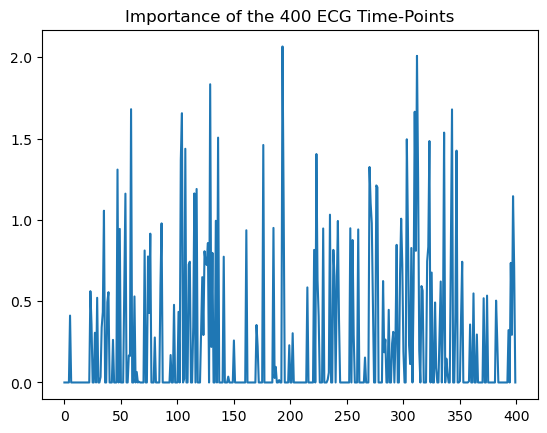

In [11]:
import matplotlib.pyplot as plt

feat_imp = cat_model.get_feature_importance()
plt.plot(feat_imp)
plt.title("Importance of the 400 ECG Time-Points")
plt.show()

# BiometricCNN: Deep Learning for ECG Biometric Identification

## Why CNNs for Biometric Identification?

To effectively utilize our full dataset for biometric identification, Convolutional Neural Networks (CNNs) offer significant advantages over tree-based models:

- **Efficient Multi-class Classification**: CNNs with Softmax output layers handle high class counts (many individuals) much more efficiently than tree-based models
- **Parameter Efficiency**: Shared weights in convolutional layers reduce the total parameter count compared to fully-connected alternatives
- **Automatic Feature Extraction**: No need for manual feature engineering of ECG characteristics

## Model Architecture

The BiometricCNN is a 1D-Convolutional Neural Network specifically designed for temporal biosignal analysis:

- **Specialized for Time Series**: Unlike standard image-based CNNs (2D), this architecture focuses on extracting patterns along the time dimension of ECG signals
- **Multi-channel Processing**: Processes both ECG leads simultaneously to capture complementary information
- **Hierarchical Feature Learning**: Extracts features at multiple temporal scales, from local voltage fluctuations to broader waveform patterns

This approach allows the network to learn discriminative patterns directly from raw, two-channel voltage signals, capturing the unique cardiac signature of each individual.

In [4]:
import torch
import torch.nn as nn

class BiometricCNN(nn.Module):
    def __init__(self, num_classes):
        super(BiometricCNN, self).__init__()
        
        # Feature Extraction: Learning the "Cardiac Signature"
        self.features = nn.Sequential(
            # Layer 1: Captures broad morphological features (P-wave, QRS, T-wave)
            # Input: (Batch, 2, 200) -> Output: (Batch, 32, 100)
            nn.Conv1d(2, 32, kernel_size=7, stride=1, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Layer 2: Captures finer details in the QRS complex
            # Output: (Batch, 64, 50)
            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Layer 3: High-level abstraction of the biometric signature
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            # Global Average Pooling: Makes the model invariant to slight shifts in R-peak alignment
            # Collapses the temporal dimension (50) to 1
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Classification: Mapping signatures to Patient Identities
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3), # Essential for preventing memorization of noise
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # 1. Pass input through conv layers
        x = self.features(x)
        
        # 2. Flatten for the fully connected layers
        # Shape change: (Batch, 128, 1) -> (Batch, 128)
        x = x.view(x.size(0), -1)
        
        # 3. Output raw logits for CrossEntropyLoss
        x = self.classifier(x)
        return x

    @torch.no_grad()
    def evaluate(self, loader, criterion, device):
        """
        Calculates Loss and Accuracy without tracking gradients.
        Essential for monitoring generalization during training.
        """
        self.eval() 
        total_loss, correct, total = 0, 0, 0

        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = self(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        return total_loss / len(loader), 100 * correct / total

# Creating Biometric CNN Training and Testing Datasets

We implement the **closed-set** approach by carefully splitting our full dataset to ensure each subject appears in both training and testing sets, maintaining the integrity of our biometric identification system while properly evaluating its performance on known individuals.

In [7]:
# Split so that heartbeats from the SAME patients appear in both sets
# 1. Flatten your X from (Patients, 10, 2, 200) to (TotalBeats, 2, 200)
# Flatten your Y from (Patients,) to (TotalBeats,)
X_flat = X.reshape(-1, 2, 200)
Y_flat = np.repeat(Y_encoded, 10) 

# 2. Perform the Random Shuffled Split
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, 
    Y_flat, 
    test_size=0.2, 
    random_state=42, 
    stratify=Y_flat
)

print(f"Train Shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test Shape: {X_test.shape}, Labels: {y_test.shape}")

Train Shape: (83776, 2, 200), Labels: (83776,)
Test Shape: (20944, 2, 200), Labels: (20944,)


## Creating Efficient PyTorch Data Pipelines

We implement specialized PyTorch DataLoaders to optimize the training and evaluation process for our ECG biometric identification system:

### Training DataLoader
- **Configuration**: `batch_size=64` with `shuffle=True`
- **Purpose**: Randomly samples batches during training to improve model generalization
- **Benefits**: 
  - Introduces variability between epochs
  - Reduces risk of memorization
  - Helps escape local minima during optimization

### Testing DataLoader
- **Configuration**: Consistent batch processing without shuffling
- **Purpose**: Provides systematic evaluation of model performance
- **Benefits**:
  - Ensures reproducible assessment
  - Maintains consistent ordering for analysis

### Implementation Impact

These DataLoaders efficiently manage memory usage by loading data in batches rather than all at once, enabling training on larger datasets while providing the PyTorch model with properly formatted tensor inputs.

In [8]:
# Create DataLoaders
from torch.utils.data import Dataset, DataLoader

class ECGIdentificationDataset(Dataset):
    def __init__(self, x_data, y_data):
        # Biometric input shape: (Patients, 10, 2, 200)
        # We need to flatten the 'Patient' and 'Beats' for simple identification,
        # OR keep them grouped. For standard ID, we treat each beat as a sample.
        
        self.x = torch.tensor(x_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# Re-initialize DataLoaders with the ENCODED labels
train_ds = ECGIdentificationDataset(X_train, y_train)
test_ds = ECGIdentificationDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

## Why CUDA is Important for PyTorch CNN Training

CUDA (Compute Unified Device Architecture) is crucial for training Convolutional Neural Networks (CNNs) with PyTorch for several important reasons:

1. **Massive Parallelization**: CNNs involve numerous matrix multiplications and convolution operations that can be parallelized. GPUs have thousands of cores designed specifically for parallel processing, while CPUs typically have only a few cores.

2. **Speed Improvement**: Training on a GPU with CUDA can be 10-100x faster than on a CPU, depending on the model complexity and dataset size.

3. **Memory Bandwidth**: GPUs offer much higher memory bandwidth than CPUs, allowing faster data transfer during training.

Moving a model to GPU in PyTorch is straightforward.

In [9]:
import torch

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print()
    #print(f"PyTorch Version: {torch.__version__}")
    #print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    #print(f"CUDA Version: {torch.version.cuda}")
else:
    print("CUDA not detected. Check drivers and PyTorch version.")

Is CUDA available? True



# Model Initialization and Configuration

Establish the core components for training our ECG biometric identification model:

1. **Hardware Configuration**: Select GPU acceleration if available, falling back to CPU otherwise
   
2. **Model Architecture**: 
   - Instantiates our custom `BiometricCNN` model
   - Configures output layer for multi-class identification (based on encoded classes)
   - Visualizes model structure using `torchinfo.summary()`

3. **Training Configuration**:
   - **Loss Function**: Cross-Entropy Loss - appropriate for multi-class classification
   - **Optimizer**: Adam with learning rate 0.001 - balances convergence speed and stability

In [10]:
from torch import optim
from torchinfo import summary

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(encoder.classes_)

model = BiometricCNN(num_classes)
# Provide an example input shape: (Batch Size, Channels, Length)
print(summary(model, input_size=(1, 2, 200)))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
BiometricCNN                             [1, 10472]                --
├─Sequential: 1-1                        [1, 128, 1]               --
│    └─Conv1d: 2-1                       [1, 32, 200]              480
│    └─ReLU: 2-2                         [1, 32, 200]              --
│    └─MaxPool1d: 2-3                    [1, 32, 100]              --
│    └─Conv1d: 2-4                       [1, 64, 100]              10,304
│    └─ReLU: 2-5                         [1, 64, 100]              --
│    └─MaxPool1d: 2-6                    [1, 64, 50]               --
│    └─Conv1d: 2-7                       [1, 128, 50]              24,704
│    └─ReLU: 2-8                         [1, 128, 50]              --
│    └─AdaptiveAvgPool1d: 2-9            [1, 128, 1]               --
├─Sequential: 1-2                        [1, 10472]                --
│    └─Linear: 2-10                      [1, 256]                  33,024
│ 

# BiometricCNN Training Pipeline

## Model Training and Evaluation Process

Implement a comprehensive 60-epoch training regimen for our ECG biometric identification model with several key components:

### Setup Phase
- Transfers model and loss function to the appropriate device (GPU/CPU)
- Initializes performance tracking dictionaries and variables
- Configures model checkpoint path

### Per-Epoch Training Cycle
1. **Training Loop**:
   - Processes mini-batches from the training data loader
   - Executes the standard PyTorch training sequence:
     - Zero gradients → Forward pass → Loss calculation → Backward pass → Optimizer step

2. **Evaluation Phase**:
   - Evaluates model performance on both training and testing datasets
   - Calculates and records loss and accuracy metrics

3. **Model Persistence**:
   - Implements model checkpointing based on test accuracy
   - Saves only the best-performing model configuration with complete state information
   - Includes epoch number, model weights, optimizer state, and accuracy

4. **Progress Reporting**:
   - Provides detailed per-epoch performance metrics
   - Highlights when new best models are saved

In [12]:
num_epochs = 100
print(f"Starting training on {device}...")

# Ensure model and loss function are on the GPU
model = model.to(device)
criterion = criterion.to(device)

# Initialize history tracking
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}
best_acc = 0.0
model_path = 'models/biometric_cnn_best.pth'

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)

    # --- EVALUATION PHASE ---
    train_loss, train_acc = model.evaluate(train_loader, criterion, device)
    test_loss, test_acc = model.evaluate(test_loader, criterion, device)

    # Store metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    # --- SAVE BEST MODEL ---
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': test_acc,
        }, model_path)
        print(f"New Best Model Saved! Accuracy: {test_acc:.2f}%")
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs}]")
    print(f"  Train -> Loss: {train_loss:.4f} | Acc: {train_acc:.4f}%")
    print(f"  Test  -> Loss: {test_loss:.4f}  | Acc: {test_acc:.4f}%")
    print("-" * 30)

Starting training on cuda...
New Best Model Saved! Accuracy: 0.14%
Epoch [01/100]
  Train -> Loss: 7.8800 | Acc: 0.1623%
  Test  -> Loss: 7.9101  | Acc: 0.1385%
------------------------------
New Best Model Saved! Accuracy: 0.48%
Epoch [02/100]
  Train -> Loss: 7.3073 | Acc: 0.4954%
  Test  -> Loss: 7.3692  | Acc: 0.4822%
------------------------------
New Best Model Saved! Accuracy: 1.25%
Epoch [03/100]
  Train -> Loss: 6.8956 | Acc: 1.4503%
  Test  -> Loss: 6.9817  | Acc: 1.2462%
------------------------------
New Best Model Saved! Accuracy: 2.55%
Epoch [04/100]
  Train -> Loss: 6.5562 | Acc: 2.9579%
  Test  -> Loss: 6.6687  | Acc: 2.5544%
------------------------------
New Best Model Saved! Accuracy: 4.52%
Epoch [05/100]
  Train -> Loss: 6.0864 | Acc: 5.1435%
  Test  -> Loss: 6.2403  | Acc: 4.5216%
------------------------------
New Best Model Saved! Accuracy: 8.03%
Epoch [06/100]
  Train -> Loss: 5.6043 | Acc: 9.1769%
  Test  -> Loss: 5.8019  | Acc: 8.0309%
------------------------

## Visualization Analysis

Create a comprehensive visualization of our BiometricCNN model's training progression through dual side-by-side plots:

**Accuracy Trajectory (Left Plot)**:
   - Tracks classification accuracy percentages across training epochs
   - Helps identify potential overfitting (widening gap between lines)

**Loss Progression (Right Plot)**:
   - Monitors the convergence of the loss function
   - Provides insight into optimization stability and learning dynamics

This visualization serves as a critical diagnostic tool for assessing model training quality, revealing patterns of convergence, potential overfitting, and the effectiveness of our hyperparameter choices for the ECG biometric identification task.

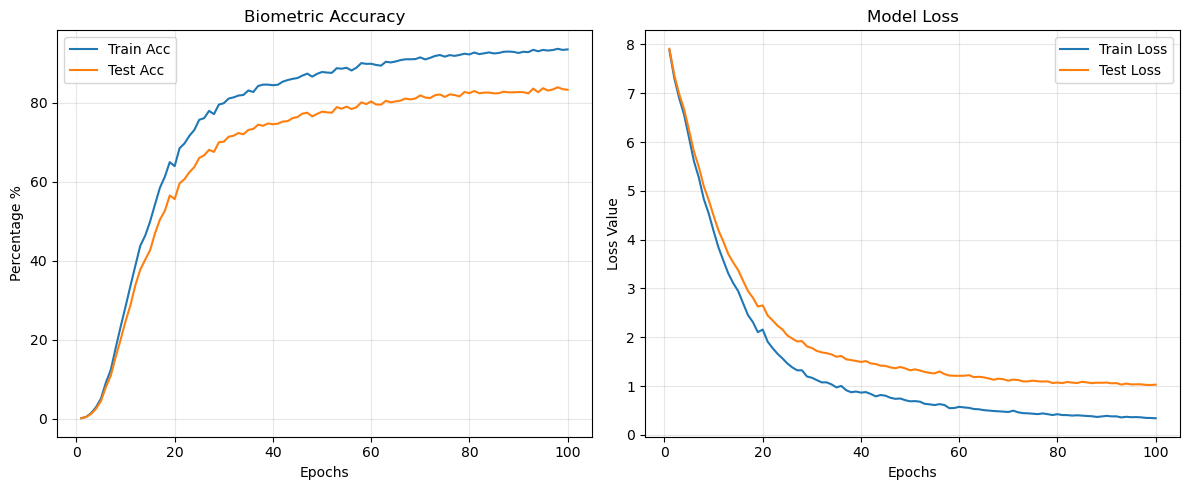

In [13]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    epochs = range(1, len(history['train_acc']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Train Acc', color='#1f77b4')
    plt.plot(epochs, history['test_acc'], label='Test Acc', color='#ff7f0e')
    plt.title('Biometric Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Percentage %')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Train Loss', color='#1f77b4')
    plt.plot(epochs, history['test_loss'], label='Test Loss', color='#ff7f0e')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_metrics(history)

# Model Performance Analysis: BiometricCNN for ECG Identification

## Diagnostic Visualization Insights

A 10% gap between training and test accuracy is a classic indicator of **overfitting**. The BiometricCNN model is starting to "memorize" the specific noise or idiosyncrasies of the heartbeats in the training set rather than learning the universal "cardiac signature" of the patients.

If training accuracy is stuck around 93%, the model might be under-parameterized (too simple) for the number of patients in PTB-XL.

To make the model more robust we can tune the architectural and data-driven aspects.

**Data Augmentation**:
- Time Shifting: Randomly roll the signal by 5-10 samples. This teaches the model that the R-peak isn't always perfectly at index 100.
- Amplitude Scaling: Multiply the signal by a random factor (e.g., 0.9 to 1.1). This mimics slight variations in skin-electrode impedance.
- Random Noise: Add a tiny amount of Gaussian noise. This prevents the CNN from relying on high-frequency "jitter" that might be unique to a single recording session.

**Architectural Refinement**:
- Increase Depth: Add one more Conv1d layer (e.g., 256 filters) before the AdaptiveAvgPool1d. This allows the model to learn more complex "meta-features" of the waveform.
- Batch Normalization: Add nn.BatchNorm1d after each convolution. This stabilizes the learning process and often allows for higher learning rates and better generalization.
- Increase Dropout from 0.3 to 0.5 in the classifier to force neurones to work more independently.
- Learning Rate Scheduler: Your loss might be "bouncing" around the minimum. Use ReduceLROnPlateau in PyTorch to drop the learning rate when the test loss stalls.
- Global Average Pooling: Instead of a giant Flatten() layer, use nn.AdaptiveAvgPool1d(1). This reduces the parameter count and often prevents overfitting in biometric tasks.


## The "Leakage" Problem

Because those 10 beats extracted from ecg records for each patient were recorded at the exact same time on the same machine, they share identical "noise" (baseline wander, powerline interference, skin contact quality). 
The model "identifies" the patient by recognizing that specific noise signature, not the biological R-peak morphology. 
This is why our training accuracy is so high - the model has already seen the "environment" of the test beats.

To do Closed-Set Identification properly, you want the model to see the patient in training, but you want to test it on a completely different segment of time that it hasn't seen.